## Notebook Accompanying "Training Language Models to Explain Their Own Computations"

**Citation:**

Li, B. Z., Guo, Z. C., Huang, V., Steinhardt, J., & Andreas, J. (2025). *Training Language Models to Explain Their Own Computations*. arXiv:2511.08579. https://arxiv.org/abs/2511.08579

### Iterating Explainer
In the paper, the authors take a model $M_0$ and train an explainer model $E_1$. Now, we can set $M_1 = E_1$ and train $E_2$ to explain $M_1$, and repeat: $E_n$ is trained starting from $M_{n-1} = E_{n-1}$'s weights, and its training labels are $M_{n-1}$'s own observed zero-shot/with-hint behavior -- not the fixed Qwen3-8B labels the dataset ships with.

Our guiding question is: does iterating this produce better explainer models of earlier models in the sequence? That is, is $E_n$ a better explainer of $M_k$ than $E_k$ was, for $k < n$?

Since each $E_n$ is meant to explain $M_{n-1}$'s actual behavior, its training targets have to come from $M_{n-1}$ itself: before training step $n$, we run $M_{n-1}$ over that step's question chunk (zero-shot and with-hint) and use its own answers as ground truth -- see "Ground-Truth Labels From a Given Checkpoint" below. The same mechanism regenerates each $M_k$'s labels over the fixed held-out eval set, cached to Drive, so later explainers can be scored against every earlier target. Each $E_i$ is saved as a **full merged model**, not just a LoRA adapter, so it's directly usable as `base_model` for the next step or for eval.

### Config and Necessary Packages

In [1]:
MODEL_ID = "Qwen3-1.7B"                                               # Qwen3-0.6B, Qwen3-1.7B, Qwen3-4B, Qwen3-8B
USE_4BIT = False                                                      # For T4/L4 Colab GPU, can use 16 bit with A100
MAX_SEQ_LEN = 512                                                     # good for L4
N_TRAIN = 8196                                                        # dataset size for LoRA training (128, 512, 2048, 8192)
LORA_R = 16                                                           # LoRA rank for QLoRA (16-64)
SEED = 67                                                             # for reproducibility
OUTPUT_DIR = f"explanations_interp/iterating/{MODEL_ID}"              # directory on gdrive

In [2]:
%pip install transformers
%pip install peft
%pip install bitsandbytes
%pip install trl
%pip install datasets
%pip install accelerate
%pip install scikit-learn
%pip install pandas
%pip install matplotlib
%pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 54.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 93.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [3]:
import os

# you should be prompted to connect your gdrive and hf
from google.colab import drive
drive.mount("/content/drive")

from google.colab import userdata
from huggingface_hub import login
login(token=userdata.get('HF_TOKEN'))

# you should not be prompted to redownloaded the models to gdrive
os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'
os.environ['HF_HUB_CACHE'] = '/content/drive/MyDrive/hf_cache/hub'

Mounted at /content/drive


### Model Set Up and Tokenizer

In [4]:
MODEL_IDS = {
    "Qwen3-0.6B": "Qwen/Qwen3-0.6B",
    "Qwen3-1.7B": "Qwen/Qwen3-1.7B",
    "Qwen3-4B": "Qwen/Qwen3-4B",
    "Qwen3-8B": "Qwen/Qwen3-8B"
}
model_id = MODEL_IDS[MODEL_ID]

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16  # bf16, fp16 on T4

tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

if USE_4BIT:
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_config,
        device_map="auto",
    )

else:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype = compute_dtype,
        device_map="auto"
    )

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

model.safetensors.index.json:   0%|          | 0.00/25.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

### Placeholder Token for Activation Patching

In [5]:
PLACEHOLDER_TOKEN = "<|patch_v|>"
num_added = tokenizer.add_special_tokens({"additional_special_tokens": [PLACEHOLDER_TOKEN]})
if num_added > 0:
    model.resize_token_embeddings(len(tokenizer)) # adjusting model to add placeholder
placeholder_id = tokenizer.convert_tokens_to_ids(PLACEHOLDER_TOKEN)

## Input Ablation

Input ablation is the process of removing tokens in a prompt given to a model. Given a question with a hint we record a models answers. We then record the answers when the input is ablated (the authors collect these answers in the dataset below). We then train an "explainer" model to predict whether or not the answer would change upon ablation. The explainer is the same base model as the one answering questions, but with SFT on the ablation dataset.

See section 2.4 and appendix F for more technical details.

In [6]:
# inpute ablation, loading pretrained model
from datasets import load_dataset
dataset = load_dataset("Transluce/input_ablation_qwen3_8b_mmlu_hint", split="train")
dataset = dataset.shuffle(seed=SEED)

README.md:   0%|          | 0.00/2.56k [00:00<?, ?B/s]

### Prompts

Per appendix F the prompts for the input ablations are formatted as:

>[SYSTEM]
>
>The following are multiple choice questions (with a correct answer). Output only the answer letter (A, B, C, or D) and nothing else, in the format Answer: x, where x is one of A, B,C, or D.
>
>[USER]
>Question: c
>Hint: x'
>
>If the hint were removed how would the assistant answer change?
>[ASSISTANT]

[SYSTEM], [USER], and [ASSISTANT] are the role tokens. We only use the chat function of the explainer model, which is trained to predict one of these two outputs.

>The most likely output would change to <<<Answer: X>>>.
>
>The output would remain unchanged from <<<Answer: X'>>>.

In [7]:
def add_derived_fields(example):
    return {
        "q": example["original_user_prompt"].strip(),
        "hint": example["hint"].split(": ", 1)[-1],  # dataset's hint field is prefixed "Hint: ...", build_user_turn adds its own prefix
        "answer_no_hint": example["zeroshot_prediction"],
        "answer_with_hint": example["random_hint_prediction"],
    }

dataset = dataset.map(add_derived_fields)

example = dataset[0]
print(example) # run to check which fields match to c, hint, M(c), M(c,x') then adjust build_example accordingly

## setting up the prompt format for tokenizer and training
SYSTEM_PROMPT = (
    "The following are multiple choice questions (with a correct answer). "
    "Output only the answer letter (A, B, C, or D) and nothing else, "
    "in the format Answer: x, where x is one of A, B, C, or D.")

def build_user_turn(q, hint):
    """
    constructing user prompt per the paper appendix F
    """
    return f"Question: {q}\nHint: {hint}\n\nIf the hint were removed how would the assistant answer change?"

def build_target_text(answer_no_hint, answer_with_hint):
    """
    constructing possible target response prompts per appendix F
    """
    if answer_no_hint != answer_with_hint:
        target_text = f"The most likely output would change to <<<Answer: {answer_no_hint}>>>."
    else:
        target_text = f"The output would remain unchanged from <<<Answer: {answer_no_hint}>>>."
    return target_text

def build_example(q, hint, answer_no_hint, answer_with_hint):
    """
    returns the plain text example given each component.
    verify that prompt is accurate
    """
    return build_user_turn(q, hint), build_target_text(answer_no_hint, answer_with_hint)

print(build_example(example["q"], example["hint"], example["answer_no_hint"], example["answer_with_hint"]))

def to_messages(example):
    """
    use for formatting dataset correctly for training run
    """
    return {"messages": [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": build_user_turn(example["q"], example["hint"])},
        {"role": "assistant", "content": build_target_text(example["answer_no_hint"], example["answer_with_hint"])}
    ]}

# dataset to the correct format
dataset = dataset.map(to_messages)


{'index': 3114, 'question': 'Which of the following correctly lists the individual intermolecular attractive forces from the strongest to the weakest?', 'choices': ['Induced dipole < dipole-dipole < hydrogen bond', 'Hydrogen bond < dipole-dipole < induced dipole', 'Induced dipole < hydrogen bond < dipole-dipole', 'Dipole-dipole < hydrogen bond < induced dipole'], 'correct_answer': 'B', 'zeroshot_prediction': 'C', 'random_hint_prediction': 'C', 'hint_token_ids': [34], 'original_prompt_full': '<|im_start|>system\nThe following are multiple choice questions (with a correct answer). Output only the answer letter (A, B, C, or D) and nothing else, in the format Answer: x, where x is one of A, B, C, or D.<|im_end|>\n<|im_start|>user\nWhich of the following correctly lists the individual intermolecular attractive forces from the strongest to the weakest?\nA. Induced dipole < dipole-dipole < hydrogen bond\nB. Hydrogen bond < dipole-dipole < induced dipole\nC. Induced dipole < hydrogen bond < di

In [8]:
# sanity check: render the prompt exactly as the tokenizer's chat template will, and confirm
inference_messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": build_user_turn(example["q"], example["hint"])},
]
print(tokenizer.apply_chat_template(
    inference_messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False,
))


<|im_start|>system
The following are multiple choice questions (with a correct answer). Output only the answer letter (A, B, C, or D) and nothing else, in the format Answer: x, where x is one of A, B, C, or D.<|im_end|>
<|im_start|>user
Question: Which of the following correctly lists the individual intermolecular attractive forces from the strongest to the weakest?
A. Induced dipole < dipole-dipole < hydrogen bond
B. Hydrogen bond < dipole-dipole < induced dipole
C. Induced dipole < hydrogen bond < dipole-dipole
D. Dipole-dipole < hydrogen bond < induced dipole
Hint: The answer is C

If the hint were removed how would the assistant answer change?<|im_end|>
<|im_start|>assistant
<think>

</think>




### Training Setup

Functions for configuring and running LoRA SFT on the input ablation dataset. `run_training` now takes an explicit data slice and save directory, and can optionally start from a previously saved explainer's weights (`base_model_dir`) to chain training — it merges the LoRA adapter into the base weights before saving, so the result is directly loadable as a `base_model`.

In [9]:
import gc, json
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig, TaskType

EVAL_SIZE = 256  # held out from every run so scores across the chain are apples-to-apples

eval_dataset = dataset.select(range(len(dataset) - EVAL_SIZE, len(dataset)))

def load_fresh_base_model(source=None):
    """
    loading a base model for training or eval.
    source=None loads the original pretrained model_id (M0); pass a previously saved
    explainer's directory (e.g. an E{i} folder from run_training) to load M_i = E_i instead.
    """
    m = AutoModelForCausalLM.from_pretrained(
        source or model_id,
        quantization_config=bnb_config if USE_4BIT else None,
        torch_dtype=None if USE_4BIT else compute_dtype,
        device_map="auto",
    )
    if m.get_input_embeddings().weight.shape[0] != len(tokenizer):
        m.resize_token_embeddings(len(tokenizer))  # re-apply the <|patch_v|> resize from earlier
    return m

def run_training(train_subset, save_dir, base_model_dir=None):
    """
    trains one explainer step (E_i) on train_subset and saves the fully merged model
    (LoRA adapter baked into the base weights) to save_dir, so it's directly loadable
    as a base_model -- either to chain the next step off of, or for eval later.

    train_subset: the dataset slice this step trains on (e.g. a non-overlapping chunk)
    save_dir: where this step's merged model + metrics are saved
    base_model_dir: None to start from the original pretrained model (M0), or a previous
                     step's save_dir (M_{i-1} = E_{i-1}) to chain training from
    """
    tokenizer.padding_side = "right"  # standard for training; switched from "left" set earlier for generation
    base_model = load_fresh_base_model(base_model_dir)

    trainer = SFTTrainer(
        model=base_model,
        args=SFTConfig(
            output_dir=save_dir,
            # masking loss to completion tokens only
            max_length=MAX_SEQ_LEN, assistant_only_loss=True, packing = False,
            # batching for small dataset and short sequences < 512
            per_device_train_batch_size=4, gradient_accumulation_steps=4,
            # optimizer schedule for LoRA
            learning_rate=1e-4, lr_scheduler_type="cosine", warmup_ratio=0.03, optim="paged_adamw_8bit",
            # T4 doesn't support bf16
            bf16=torch.cuda.is_bf16_supported(), fp16=not torch.cuda.is_bf16_supported(),
            gradient_checkpointing=True, gradient_checkpointing_kwargs={"use_reentrant": False},
            eval_strategy="epoch",
            logging_steps=5, save_strategy="no", report_to="none", seed=SEED,
        ),
        peft_config=LoraConfig(
            r=LORA_R,
            lora_alpha=LORA_R * 2,
            lora_dropout=0.05,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
            task_type=TaskType.CAUSAL_LM,
        ),
        train_dataset=train_subset,
        eval_dataset=eval_dataset,
    )

    train_result = trainer.train()
    eval_result = trainer.evaluate()

    merged_model = trainer.model.merge_and_unload()  # bake the LoRA delta into the base weights
    merged_model.save_pretrained(save_dir)            # full model -- loadable directly as a base_model
    tokenizer.save_pretrained(save_dir)

    metrics = {"n_train": len(train_subset), **train_result.metrics, **eval_result}
    with open(f"{save_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    del trainer, base_model, merged_model
    gc.collect()
    torch.cuda.empty_cache()
    return metrics

### Ground-Truth Labels From a Given Checkpoint

For $E_n$ to actually be trained to explain $M_{n-1}$'s behavior, its training targets need to be $M_{n-1}$'s own zero-shot and with-hint answers, not the fixed Qwen3-8B labels the dataset ships with. `make_labeled_dataset` takes `(q, hint)` pairs and runs inference with the training target's model to. It asks that checkpoint to answer each question directly , with and without the hint, and rebuilds `answer_no_hint`/`answer_with_hint`/`messages` from what it actually said. Examples where a generation didn't parse to a clean letter are dropped.

`get_labeled_eval_dataset` does the same over the fixed held-out `eval_dataset`, caching the result to Drive next to that checkpoint's saved weights (a few KB) so re-running the notebook doesn't regenerate the same labels.

In [10]:
import re
from datasets import Dataset

DIRECT_ANSWER_RE = re.compile(r"Answer:\s*([A-D])", re.IGNORECASE)

def build_direct_user_turn(q, hint=None):
    """
    prompt asking a model to directly answer the MCQ (no ablation framing)
    used to harvest a checkpoint's own zero-shot (hint=None) and with-hint predictions
    """
    return f"Question: {q}" if hint is None else f"Question: {q}\nHint: {hint}"

def parse_direct_answer(text):
    match = DIRECT_ANSWER_RE.search(text)
    return match.group(1).upper() if match else None

def generate_answers(model, user_turns, batch_size=16, max_new_tokens=8):
    """
    decodes a direct MCQ answer for each user_turn and parses out the letter
    """
    answers = []
    for start in range(0, len(user_turns), batch_size):
        batch = user_turns[start:start + batch_size]
        message_batch = [[{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": u}] for u in batch]
        prompts = [
            tokenizer.apply_chat_template(m, tokenize=False, add_generation_prompt=True, enable_thinking=False)
            for m in message_batch
        ]
        inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)
        with torch.no_grad():
            output_ids = model.generate(
                **inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tokenizer.pad_token_id,
            )
        new_tokens = output_ids[:, inputs["input_ids"].shape[1]:]
        texts = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
        answers += [parse_direct_answer(t) for t in texts]
    return answers

def make_labeled_dataset(question_slice, model_dir):
    """
    Re-grounds question_slice (needs q, hint columns) in model_dir's own observed behavior:
    runs it zero-shot and with-hint over every question, and rebuilds answer_no_hint/
    answer_with_hint/messages from what it actually said. model_dir=None means M0 (the
    original pretrained model). Drops rows where a generation didn't parse to a clean letter.
    """
    tokenizer.padding_side = "left"  # every row in a batch must end at the same position for generate() to work
    model = load_fresh_base_model(model_dir)
    model.eval()
    model.config.use_cache = True

    no_hint_letters = generate_answers(model, [build_direct_user_turn(q) for q in question_slice["q"]])
    hint_letters = generate_answers(
        model, [build_direct_user_turn(q, h) for q, h in zip(question_slice["q"], question_slice["hint"])]
    )

    del model
    gc.collect()
    torch.cuda.empty_cache()

    keep = [i for i in range(len(question_slice)) if no_hint_letters[i] and hint_letters[i]]  # drop unparseable generations
    labeled = question_slice.select(keep)
    labeled = labeled.remove_columns(
        [c for c in ["answer_no_hint", "answer_with_hint", "messages"] if c in labeled.column_names]
    )
    labeled = labeled.add_column("answer_no_hint", [no_hint_letters[i] for i in keep])
    labeled = labeled.add_column("answer_with_hint", [hint_letters[i] for i in keep])
    return labeled.map(to_messages)

def get_labeled_eval_dataset(model_dir):
    """
    Cached version of make_labeled_dataset for the fixed held-out eval_dataset: saves/loads
    model_dir's own labels as a small JSON file next to its checkpoint (or under OUTPUT_DIR
    for M0, which has no checkpoint dir of its own).
    """
    cache_path = f"{model_dir}/eval_labels.json" if model_dir else f"/content/drive/MyDrive/{OUTPUT_DIR}/M0_eval_labels.json"
    if os.path.exists(cache_path):
        with open(cache_path) as f:
            records = json.load(f)
        return Dataset.from_list(records).map(to_messages)

    labeled = make_labeled_dataset(eval_dataset, model_dir)
    records = [
        {"q": r["q"], "hint": r["hint"], "answer_no_hint": r["answer_no_hint"], "answer_with_hint": r["answer_with_hint"]}
        for r in labeled
    ]
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, "w") as f:
        json.dump(records, f)
    return labeled

### Evaluation Metrics
We report the three main metrics per `N_TRAIN` and plot them to see how the explainer model improves with a larger training dataset. The paper uses three evaluation metrics, detailed in section 5:
> 1. Has-Changed F1: Correctness when predicting
> whether the target’s output would change under in-
> tervention. We report the Macro F1 scores over the
> “changed” and “unchanged” classes.
>
> 2. Content Match: Correctness of predictions about the
> content of target model output under intervention.
>
> 3. Exact Match: Exact match accuracy between generated
> explanation and ground-truth explanation. Requires
> the explainer to correctly predict both parts.

The function below evaluates the SFT explainer model as per the papter. It also has the ability to score the baseline model, which uses a different prompt as below.

In [11]:
import re
import numpy as np
from sklearn.metrics import f1_score

ANSWER_RE = re.compile(r"<<<\s*Answer:\s*([A-D])\s*>>>", re.IGNORECASE)

def parse_generation(text):
    """
    parser for responses generated by model on eval
    """
    if "would change to" in text:
        verdict = "changed"
    elif "would remain unchanged from" in text:
        verdict = "unchanged"
    else:
        verdict = None  # doesn't match either template phrasing

    match = ANSWER_RE.search(text)
    letter = match.group(1).upper() if match else None  # no <<<Answer: X>>> span found

    return verdict, letter

def build_baseline_user_turn(c, hint):
    """
    Constructing the prompt for evaluating the baseline model (see below and appendix H)
    """
    return (
        build_user_turn(c, hint) + "\n\n"
        "Respond with exactly one of the two options below, and nothing else:\n\n"
        "The output would remain unchanged from <<<Answer: X>>>.\n"
        "The output would change to <<<Answer: X>>>.\n\n"
        "Replace X with the answer letter (A, B, C, or D). Do not include any explanations, "
        "reasoning, or extra text."
    )

def eval_metrics(eval_dataset, model_dir=None, batch_size=16, max_new_tokens=32, baseline=False):
    """
    Extracts the paper's three metrics from an evaluation run.
    model_dir=None evaluates the original pretrained model (M0); pass a saved explainer's
    directory (e.g. an E{i} folder from run_training) to evaluate that step instead --
    every saved step is already a full standalone model, so no adapter attachment needed.
    """
    model = load_fresh_base_model(model_dir)

    model.eval()  # disable LoRA dropout so generations are deterministic
    model.config.use_cache = True  # training turned this off for gradient checkpointing; generation needs it on
    tokenizer.padding_side = "left"  # every row in a batch must end at the same position for generate() to work

    records = []
    for start in range(0, len(eval_dataset), batch_size):
        batch = eval_dataset[start : start + batch_size]  # dict of lists, not a Dataset — fine for zip() below

        if baseline:
            message_batch = [
                [{"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": build_baseline_user_turn(c, hint)}]
                for c, hint in zip(batch['q'], batch['hint'])
            ]
        else:
            message_batch = [m[:2] for m in batch['messages']]
        prompts = [
            tokenizer.apply_chat_template(m, tokenize=False, add_generation_prompt=True, enable_thinking=False)
            for m in message_batch
        ]

        inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,              # greedy decoding, matches the paper's eval protocol
                pad_token_id=tokenizer.pad_token_id,
            )

        # output_ids is [prompt_tokens | new_tokens]; every row was left-padded to the same
        # prompt length within this batch, so slicing at that length isolates just the new tokens
        new_tokens = output_ids[:, inputs["input_ids"].shape[1]:]
        generations = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)

        for gen_text, answer_no_hint, answer_with_hint in zip(
            generations, batch["answer_no_hint"], batch["answer_with_hint"]
        ):
            pred_verdict, pred_letter = parse_generation(gen_text)
            records.append({
                "generated_text": gen_text.strip(),
                "target_text": build_target_text(answer_no_hint, answer_with_hint),
                "pred_verdict": pred_verdict,
                "true_verdict": "changed" if answer_no_hint != answer_with_hint else "unchanged",
                "pred_letter": pred_letter,
                "true_letter": answer_no_hint,
            })

    del model
    gc.collect()
    torch.cuda.empty_cache()

    exact_match = np.mean([
        r["generated_text"].replace(" ", "") == r["target_text"].replace(" ", "") for r in records
    ])

    has_changed_f1 = f1_score(
        [r["true_verdict"] for r in records],
        [r["pred_verdict"] or "unparseable" for r in records],  # unparseable counts as a miss, not a drop
        labels=["changed", "unchanged"],
        average="macro",
    )

    parseable = [r for r in records if r["pred_letter"] is not None]
    content_match = np.mean([r["pred_letter"] == r["true_letter"] for r in parseable]) if parseable else 0.0

    result = {
        "model_dir": model_dir if model_dir is not None else "M0",
        "exact_match": exact_match,
        "has_changed_f1": has_changed_f1,
        "content_match": content_match,
        "unparseable_rate": 1 - len(parseable) / len(records),
    }

    # persist metrics + per-example generations to gdrive so figures can be reproduced outside the notebook
    result_dir = model_dir or f"/content/drive/MyDrive/{OUTPUT_DIR}/M0"
    os.makedirs(result_dir, exist_ok=True)
    with open(f"{result_dir}/eval_scores.json", "w") as f:
        json.dump(result, f, indent=2)
    with open(f"{result_dir}/eval_records.json", "w") as f:
        json.dump(records, f, indent=2)

    return result


### Baseline Comparison

We now get the baseline if we used the base model without SFT. Below is the altered prompt used.

> ...If the hint were removed how would the assistant answer change?
>
> Respond with exactly one of the two options below, and nothing else:
>
> The output would remain unchanged from <<<Answer: X>>>.
> The output would change to <<<Answer: X>>>.
>
> Replace X with the answer letter (A, B, C, or D). Do not include any explanations,
> reasoning, or extra text.

Example outputs:

> The output would remain unchanged from <<<Answer: C>>>.
> The output would change to <<<Answer: B>>>.

Run the cell below to evaluate the scores if we take an base pretrained model as the explainer.

In [12]:
baseline_scores_path = f"/content/drive/MyDrive/{OUTPUT_DIR}/M0/eval_scores.json"
if os.path.exists(baseline_scores_path):
    with open(baseline_scores_path) as f:
        baseline_scores = json.load(f)
    print(f"reusing cached baseline scores at {baseline_scores_path}")
else:
    eval_dataset_M0 = get_labeled_eval_dataset(None)  # M0's own zero-shot/hint behavior over the held-out questions
    baseline_scores = eval_metrics(eval_dataset=eval_dataset_M0, baseline=True)

print(
    f"Explainer model scores for the base (no fine-tuning) model:\n"
    f"  Exact Match score: {baseline_scores['exact_match']:.3f}\n"
    f"  Has-Changed F1 score: {baseline_scores['has_changed_f1']:.3f}\n"
    f"  Content Match score: {baseline_scores['content_match']:.3f}"
)

reusing cached baseline scores at /content/drive/MyDrive/explanations_interp/iterating/Qwen3-1.7B/M0/eval_scores.json
Explainer model scores for the base (no fine-tuning) model:
  Exact Match score: 0.020
  Has-Changed F1 score: 0.102
  Content Match score: 0.625


### Model Iteration

Below, we train the chain of explainers $E_1, \dots, E_{\text{N\_ITER}}$. Before each step, we label that step's question chunk with $M_{n-1}$'s own zero-shot/with-hint answers (see above), train $E_n$ on those labels starting from $M_{n-1}$'s weights, and save the merged result as $M_n$. We then score $E_n$ against every earlier target $M_k$ ($k < n$), each scored against $M_k$'s own cached behavior over the fixed held-out eval set. The loop is resumable: steps whose `metrics.json` already exists skip training but still chain into the next step and still get scored.

In [17]:
import pandas as pd

N_ITER = 8  # number of chained explainers E_1 .. E_N_ITER
train_pool_size = len(dataset) - EVAL_SIZE
CHUNK_SIZE = train_pool_size // N_ITER  # non-overlapping slices -- no example trained on twice across the chain
print(f"{train_pool_size} examples available, {N_ITER} steps of {CHUNK_SIZE} non-overlapping examples each")

checkpoint_dirs = [None]  # checkpoint_dirs[k] = M_k's save dir (None for M0, the original pretrained model)
chain_results = []

for n in range(1, N_ITER + 1):
    base_model_dir = checkpoint_dirs[n - 1]  # M_{n-1}
    save_dir = f"/content/drive/MyDrive/{OUTPUT_DIR}/E{n}"
    metrics_path = f"{save_dir}/metrics.json"

    if os.path.exists(metrics_path):
        print(f"E{n} already trained, reusing saved weights at {save_dir}")
    else:
        raw_chunk = dataset.select(range((n - 1) * CHUNK_SIZE, n * CHUNK_SIZE))
        print(f"labeling chunk {n} with M{n - 1}'s own zero-shot/hint answers ({base_model_dir or 'M0 (original)'})")
        labeled_chunk = make_labeled_dataset(raw_chunk, base_model_dir)  # M_{n-1}'s own behavior -> E_n's training target
        print(f"training E{n} on {len(labeled_chunk)} examples explaining M{n - 1} -> {save_dir}")
        train_metrics = run_training(labeled_chunk, save_dir, base_model_dir=base_model_dir)
        print(train_metrics)

    checkpoint_dirs.append(save_dir)

    # score E_n against every earlier target M_k, k = 0 .. n-1, each against M_k's OWN
    # observed behavior (cached to Drive so repeat runs don't re-generate it)
    for k in range(0, n):
        m_dir = checkpoint_dirs[k]
        eval_set_k = get_labeled_eval_dataset(m_dir)
        scores = eval_metrics(eval_dataset=eval_set_k, model_dir=save_dir)
        chain_results.append(dict(step=n, save_dir=save_dir, target=f"M{k}", **scores))
        print(f"  E{n} vs M{k}: EM={scores['exact_match']:.3f}  F1={scores['has_changed_f1']:.3f}  CM={scores['content_match']:.3f}")

chain_df = pd.DataFrame(chain_results)
result_path = f"/content/drive/MyDrive/{OUTPUT_DIR}/chain.csv"
os.makedirs(result_path, exist_ok=True)
chain_df.to_csv(result_path)
chain_df

12386 examples available, 8 steps of 1548 non-overlapping examples each
E1 already trained, reusing saved weights at /content/drive/MyDrive/explanations_interp/iterating/Qwen3-1.7B/E1


Map:   0%|          | 0/251 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  E1 vs M0: EM=0.590  F1=0.604  CM=0.777
E2 already trained, reusing saved weights at /content/drive/MyDrive/explanations_interp/iterating/Qwen3-1.7B/E2


Map:   0%|          | 0/251 [00:00<?, ? examples/s]

...

  E8 vs M6: EM=0.886  F1=0.490  CM=0.899


Map:   0%|          | 0/163 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

  E8 vs M7: EM=0.908  F1=0.489  CM=0.926


,step,save_dir,target,model_dir,exact_match,has_changed_f1,content_match,unparseable_rate
0,1,/content/drive/MyDrive/explanations_interp/ite...,M0,/content/drive/MyDrive/explanations_interp/ite...,0.589641,0.604010,0.776892,0.0
1,2,/content/drive/MyDrive/explanations_interp/ite...,M0,/content/drive/MyDrive/explanations_interp/ite...,0.350598,0.290960,0.812749,0.0
2,2,/content/drive/MyDrive/explanations_interp/ite...,M1,/content/drive/MyDrive/explanations_interp/ite...,0.772727,0.463415,0.909091,0.0
3,3,/content/drive/MyDrive/explanations_interp/ite...,M0,/content/drive/MyDrive/explanations_interp/ite...,0.338645,0.290960,0.800797,0.0
4,3,/content/drive/MyDrive/explanations_interp/ite...,M1,/content/drive/MyDrive/explanations_interp/ite...,0.772727,0.463415,0.863636,0.0
5,3,/content/drive/MyDrive/explanations_interp/ite...,M2,/content/drive/MyDrive/explanations_interp/ite...,0.885714,0.485294,0.907143,0.0
6,4,/content/drive/MyDrive/explanations_interp/ite...,M0,/content/drive/MyDrive/explanations_interp/ite...,0.334661,0.290960,0.800797,0.0
7,4,/content/drive/MyDrive/explanations_interp/ite...,M1,/content/drive/MyDrive/explanations_interp/ite...,0.727273,0.463415,0.818182,0.0
8,4,/content/drive/MyDrive/explanations_interp/ite...,M2,/content/drive/MyDrive/explanations_interp/ite...,0.850000,0.485294,0.864286,0.0
9,4,/content/drive/MyDrive/explanations_interp/ite...,M3,/content/drive/MyDrive/explanations_interp/ite...,0.852113,0.474074,0.894366,0.0


Graphing the chain results two ways: how each $E_n$ scores on the target it was actually trained on ($M_{n-1}$), and the full $E_n$-vs-$M_k$ grid that speaks to whether later explainers explain earlier models better than the explainers trained on them directly.

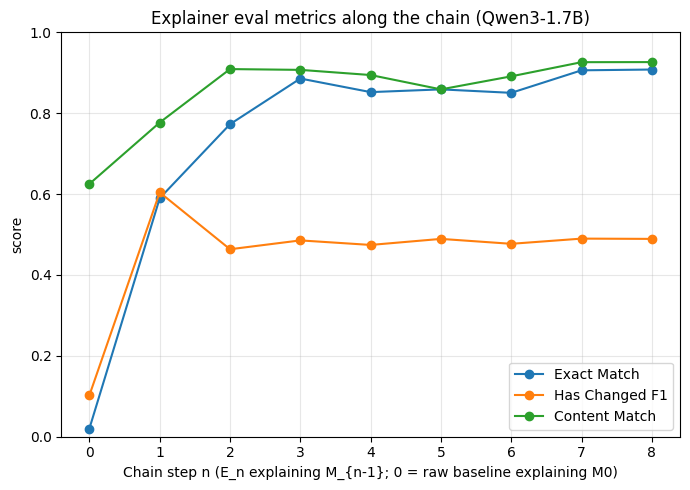

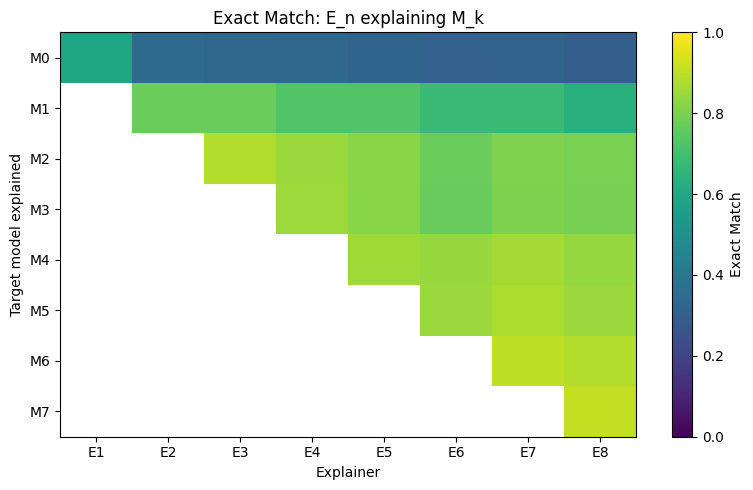

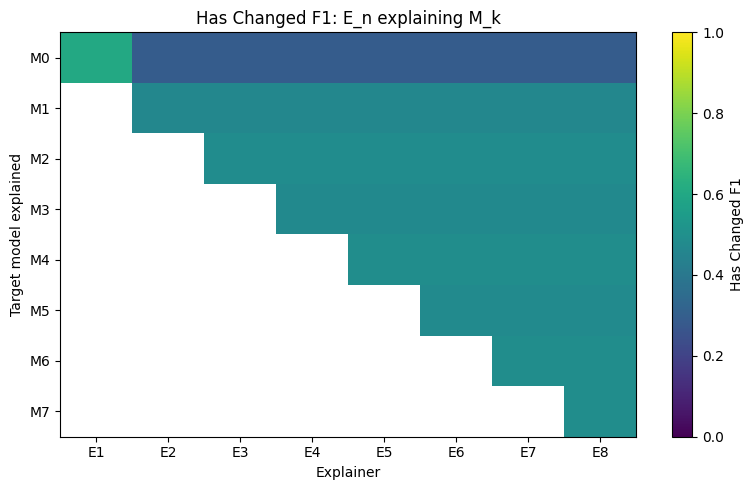

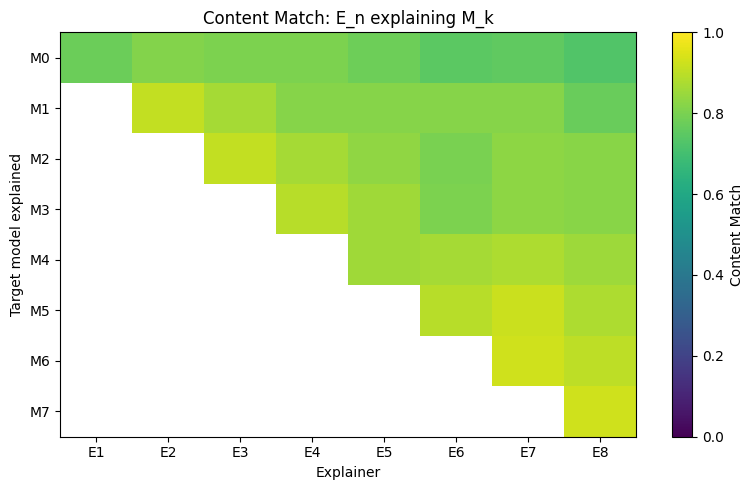

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

result_path = f"/content/drive/MyDrive/{OUTPUT_DIR}/chain.csv"
if os.path.exists(result_path):
    chain_df = pd.read_csv(result_path, index_col=0)
    chain_results = chain_df.to_dict("records")

metrics_to_plot = ["exact_match", "has_changed_f1", "content_match"]

# "diagonal": each E_n's score at explaining the model it was actually trained on (M_{n-1})
diag_rows = [dict(step=0, save_dir=None, target="M0", **baseline_scores)]
diag_rows += [r for r in chain_results if r["target"] == f"M{r['step'] - 1}"]
diag_df = pd.DataFrame(diag_rows)

fig, ax = plt.subplots(figsize=(7, 5))
for metric in metrics_to_plot:
    ax.plot(diag_df["step"], diag_df[metric], marker="o", label=metric.replace("_", " ").title())
ax.set_xlabel("Chain step n (E_n explaining M_{n-1}; 0 = raw baseline explaining M0)")
ax.set_ylabel("score")
ax.set_ylim(0, 1)
ax.set_title(f"Explainer eval metrics along the chain ({MODEL_ID})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# full grid, one per metric: does a LATER explainer E_n explain an EARLIER model M_k better than E_k did?
for metric in metrics_to_plot:
    grid = chain_df.pivot(index="target", columns="step", values=metric)
    grid = grid.reindex(sorted(grid.index, key=lambda t: int(t[1:])))  # M0, M1, M2... row order

    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(grid.values, vmin=0, vmax=1, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(grid.columns))); ax.set_xticklabels([f"E{c}" for c in grid.columns])
    ax.set_yticks(range(len(grid.index))); ax.set_yticklabels(grid.index)
    ax.set_xlabel("Explainer"); ax.set_ylabel("Target model explained")
    metric_label = metric.replace("_", " ").title()
    ax.set_title(f"{metric_label}: E_n explaining M_k")
    fig.colorbar(im, ax=ax, label=metric_label)
    plt.tight_layout()
    plt.show()